In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.layers import LSTM, Dense, Input, Layer
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Attention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

C:\Users\hercd\AppData\Local\Temp\ipykernel_17564\2762856314.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [9]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_17564\2454868855.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)


(                     Kwh            name  temp  feelslike  dew  humidity  \
 datetime                                                                   
 2022-01-01 00:00:00  0.0  Kozani, Greece   6.0        4.4  2.0     75.51   
 2022-01-01 01:00:00  0.0  Kozani, Greece   6.0        5.0  2.0     75.51   
 2022-01-01 02:00:00  0.0  Kozani, Greece   4.9        3.2  2.0     81.61   
 2022-01-01 03:00:00  0.0  Kozani, Greece   4.0        4.0  1.0     80.80   
 2022-01-01 04:00:00  0.0  Kozani, Greece   3.0        1.6  2.0     93.14   
 
                      precip  snow  snowdepth  windgust  windspeed  winddir  \
 datetime                                                                     
 2022-01-01 00:00:00     0.0   0.0        0.0      19.8        7.6    240.0   
 2022-01-01 01:00:00     0.0   0.0        0.0      19.8        5.4    298.1   
 2022-01-01 02:00:00     0.0   NaN        0.0      20.5        7.6    301.0   
 2022-01-01 03:00:00     0.0   NaN        0.0      20.5        3

In [10]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [11]:
data['solarradiation'].fillna(mean_13_00, inplace=True)
data.isna().sum()

C:\Users\hercd\AppData\Local\Temp\ipykernel_17564\2812345863.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['solarradiation'].fillna(mean_13_00, inplace=True)


Kwh                   0
name                  0
temp                  0
feelslike             0
dew                   0
humidity              0
precip                0
snow                 53
snowdepth             0
windgust              0
windspeed             0
winddir               0
sealevelpressure      0
cloudcover            0
visibility          278
solarradiation        0
solarenergy           1
uvindex               1
conditions            0
icon                  0
dtype: int64

In [39]:
data_picked = data[['Kwh', 'temp', 'dew', 'humidity', 'precip', 'windgust', 'windspeed', 'winddir', 'cloudcover', 'solarradiation', 'sealevelpressure', 'conditions']]

In [40]:
data_picked = data_picked[data_picked['solarradiation'] != 0]
data_picked.shape

(11809, 12)

In [19]:
data_picked.describe()

,Kwh,temp,dew,humidity,precip,windgust,windspeed,winddir,cloudcover,solarradiation,sealevelpressure
count,11809.000000,11809.000000,11809.000000,11809.000000,11809.000000,11809.000000,11809.000000,11809.000000,11809.000000,11809.000000,11809.000000
mean,0.281727,16.407308,5.016310,52.164304,0.069717,18.013032,7.992912,179.561733,48.108798,328.632282,1016.729545
std,0.235991,8.937548,6.640758,22.564062,1.186322,10.106656,7.149722,137.692359,36.278914,283.158668,5.864288
min,0.000000,-9.000000,-20.000000,8.300000,0.000000,1.100000,0.000000,0.000000,0.000000,0.900000,985.000000
25%,0.052700,10.000000,1.000000,33.570000,0.000000,10.800000,0.000000,20.000000,21.400000,67.000000,1013.000000
50%,0.243800,16.000000,6.000000,47.810000,0.000000,15.500000,7.600000,160.000000,50.000000,259.000000,1017.000000
75%,0.483700,23.000000,10.000000,68.770000,0.000000,23.400000,11.200000,330.000000,88.300000,542.000000,1020.000000
max,0.809800,40.000000,23.000000,100.000000,94.634000,72.000000,46.400000,360.000000,100.000000,1157.000000,1038.000000


In [20]:
tc = data_picked.corr()

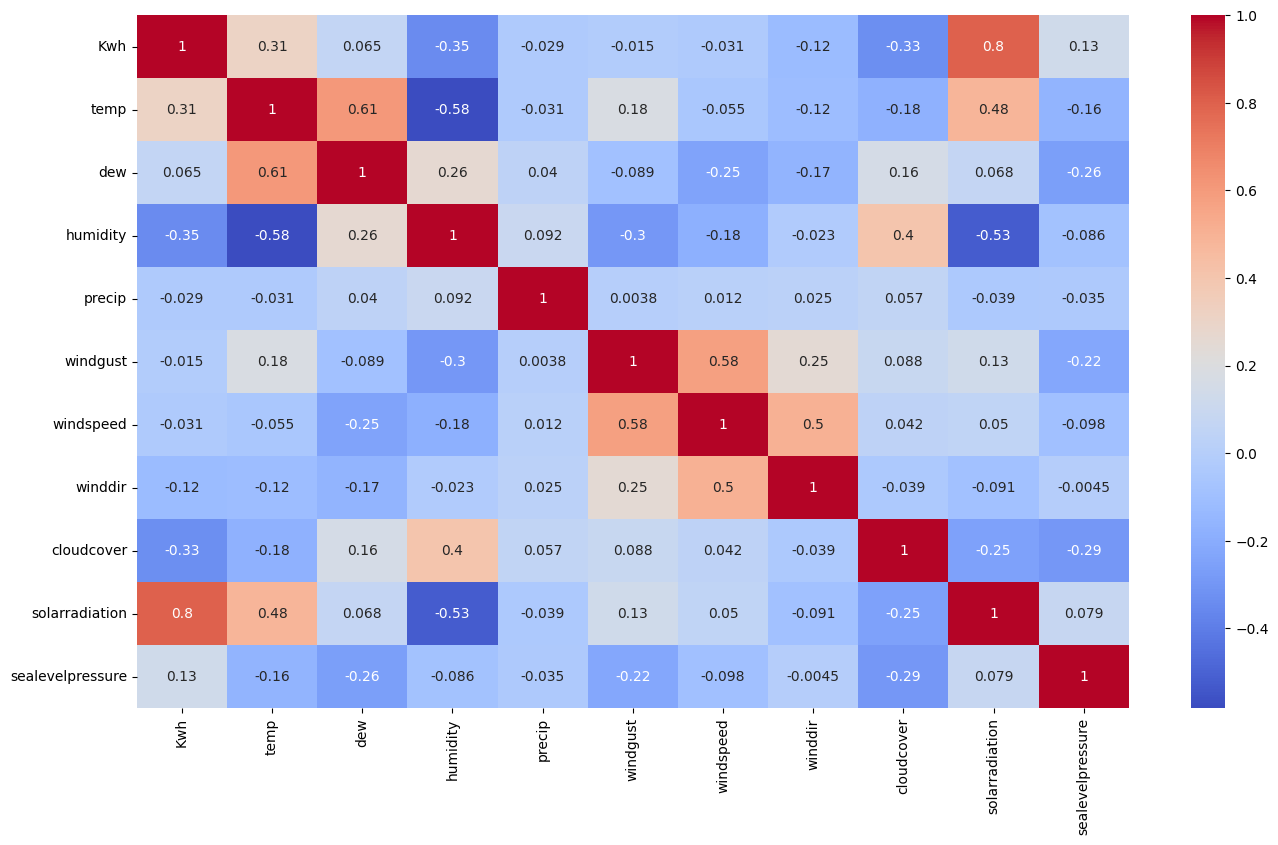

In [21]:
plt.figure(figsize= (16, 9))
sns.heatmap(tc, annot= True, cmap = "coolwarm")
plt.show()

In [25]:
data['conditions'].unique()

array(['Clear', 'Partially cloudy', 'Overcast', 'Rain, Overcast',
       'Rain, Partially cloudy', 'Snow, Overcast',
       'Snow, Partially cloudy', 'Snow', 'Snow, Rain, Overcast',
       'Snow, Rain, Partially cloudy', 'Snow, Rain', 'Rain'], dtype=object)

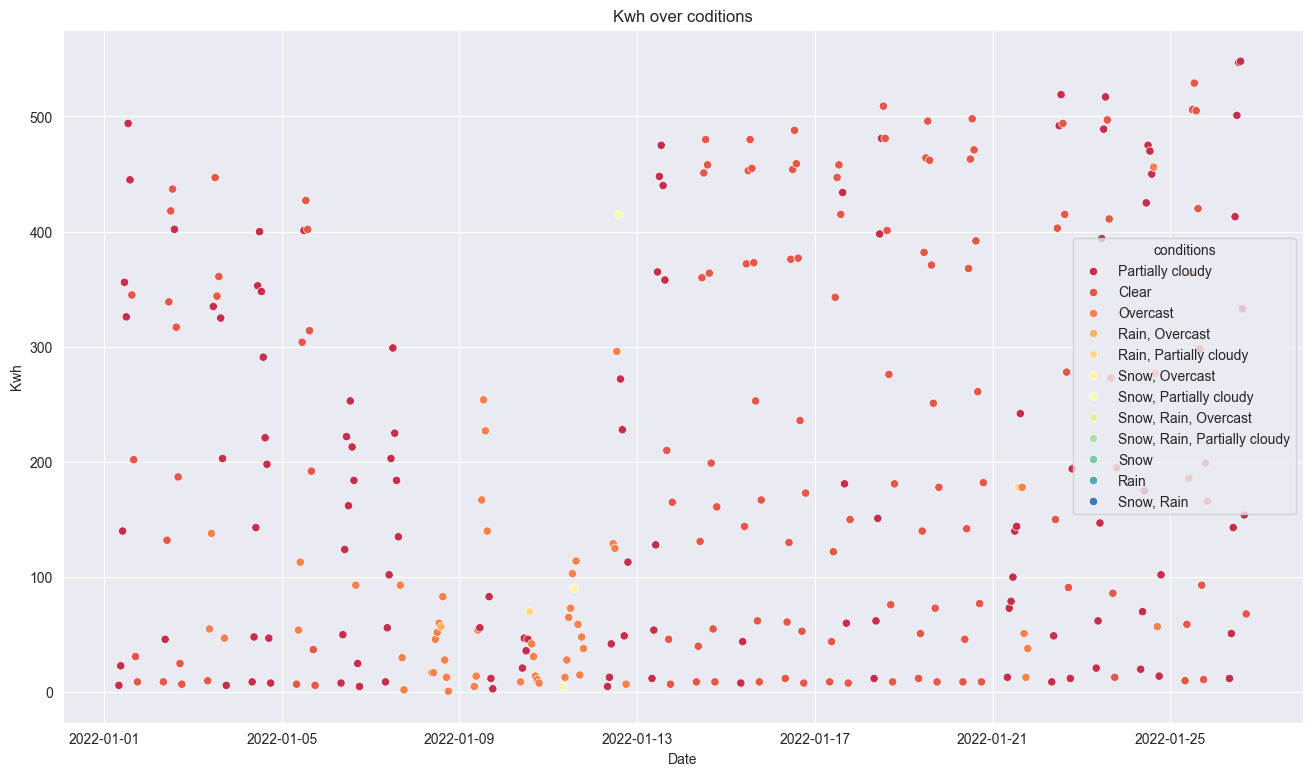

In [43]:
sns.set_style('darkgrid')
plt.figure(figsize= (16, 9))
sns.scatterplot(y = data_picked['solarradiation'][:300], x= data_picked.index, hue= data_picked['conditions'], palette= 'Spectral')
plt.xlabel('Date')
plt.ylabel('solar rad')
plt.title('solar rad over coditions')
plt.show()

# Forecasted Outliers Analysis

In [44]:
df_picked = data[["temp", "humidity", "winddir", "solarradiation", "cloudcover", "Kwh"]]
df_picked[df_picked["solarradiation"].isna()], df_picked.iloc[-1]
print(df_picked.head(), "\n", df_picked.info(), "\n", df_picked.shape)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21983 entries, 2022-01-01 00:00:00 to 2024-07-04 23:00:00
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temp            21983 non-null  float64
 1   humidity        21983 non-null  float64
 2   winddir         21983 non-null  float64
 3   solarradiation  21983 non-null  float64
 4   cloudcover      21983 non-null  float64
 5   Kwh             21983 non-null  float64
dtypes: float64(6)
memory usage: 1.2 MB
                     temp  humidity  winddir  solarradiation  cloudcover  Kwh
datetime                                                                     
2022-01-01 00:00:00   6.0     75.51    240.0             0.0         0.0  0.0
2022-01-01 01:00:00   6.0     75.51    298.1             0.0         0.0  0.0
2022-01-01 02:00:00   4.9     81.61    301.0             0.0        40.9  0.0
2022-01-01 03:00:00   4.0     80.80    294.8             0.0       

In [55]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :5]]
        x.append(row)
        real_val = df_as_np[i + size][5]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [56]:
scaler = StandardScaler()
df_sacled = scaler.fit_transform(df_picked.iloc[:, :5])
df_sacled = pd.DataFrame(df_sacled)
df_sacled.tail(20)

,0,1,2,3,4
21963,0.294464,0.750458,0.824637,-0.667640,1.345699
21964,0.294464,0.531665,0.677607,-0.667640,1.345699
21965,0.408365,0.334574,0.898152,-0.667640,1.036709
21966,0.408365,0.141026,0.971668,-0.380218,1.036709
21967,0.408365,-0.041449,0.898152,-0.175998,1.036709
21968,0.522267,-0.202223,0.971668,0.357245,1.036709
21969,0.750070,-0.633608,0.971668,0.656012,1.036709
21970,0.977872,-0.868789,0.898152,2.255741,1.036709
21971,1.319577,-1.265186,0.971668,0.822414,-0.585484
21972,1.319577,-1.166419,0.751122,0.323208,-0.585484


In [57]:
df_sacled_reset = df_sacled.reset_index(drop=True)
df_picked_reset = df_picked.reset_index(drop=True)

# Concatenate the DataFrames
df_sacled = pd.concat([df_sacled_reset, df_picked_reset["Kwh"]], axis=1)
df_sacled


,0,1,2,3,4,Kwh
0,-0.844550,0.677822,0.163000,-0.667640,-1.229211,0.0000
1,-0.844550,0.677822,0.590124,-0.667640,-1.229211,0.0000
2,-0.969842,0.947992,0.611443,-0.667640,-0.176073,0.0000
3,-1.072353,0.912117,0.565864,-0.667640,-0.250745,0.0000
4,-1.186254,1.458657,0.547485,-0.667640,-0.155474,0.0000
...,...,...,...,...,...,...
21978,1.205675,-0.843987,-0.278091,0.115206,0.812692,0.0592
21979,1.091774,-0.856388,-0.331022,-0.278108,0.874490,0.0085
21980,0.863971,-0.479036,-1.601364,-0.633603,0.411006,0.0000
21981,0.750070,-0.179635,-1.601364,-0.667640,0.457355,0.0000


In [58]:
x_2, y_2 = df_to_x_y(df_sacled, size= 24)
x_2.shape, y_2.shape

((21959, 24, 5), (21959,))

In [59]:
x_train_2 , y_train_2 = x_2[:int(0.8*len(x_2))], y_2[: int(0.8*len(y_2))]
x_val_2, y_val_2 = x_2[int(0.8*len(x_2)): int(0.9*len(x_2))], y_2[int(0.8*len(y_2)): int(0.9*len(y_2))]
x_test_2, y_test_2 = x_2[int(0.9*len(x_2)):], y_2[int(0.9*len(y_2)):]

x_train_2.shape, y_train_2.shape, x_val_2.shape, y_val_2.shape, x_test_2.shape, y_test_2.shape

((17567, 24, 5), (17567,), (2196, 24, 5), (2196,), (2196, 24, 5), (2196,))

In [60]:
checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [61]:
input_shape = (24, 5)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(16, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 64)    │     17,920 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 64)    │        256 │ lstm[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 64)    │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24, 16)    │      1,040 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 16)    │         64 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         17 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,297 (75.38 KB)

 Trainable params: 19,137 (74.75 KB)

 Non-trainable params: 160 (640.00 B)

In [63]:
history = model_1.fit(x_train_2, y_train_2, 
            validation_data = (x_val_2, y_val_2), 
            epochs = 40,
            batch_size= 32,
            callbacks=[checkpoint_callback]
            )

Epoch 1/40
548/549 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0119 - root_mean_squared_error: 0.1092
Epoch 1: val_loss improved from 0.01626 to 0.01000, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0119 - root_mean_squared_error: 0.1092 - val_loss: 0.0100 - val_root_mean_squared_error: 0.1000
Epoch 2/40
547/549 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0090 - root_mean_squared_error: 0.0949
Epoch 2: val_loss improved from 0.01000 to 0.00868, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0090 - root_mean_squared_error: 0.0949 - val_loss: 0.0087 - val_root_mean_squared_error: 0.0931
Epoch 3/40
548/549 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0080 - root_mean_squared_error: 0.0895
Epoch 3: val_loss improved from 0.00868 to 0.00617, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation

In [64]:
test_predictions_2 = model_1.predict(x_test_2).flatten()
test_results_2 = pd.DataFrame({"Val Predictions" : test_predictions_2, "Real Data" : y_test_2})
test_results_2
test_results_2.index = df_picked.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [66]:
test_results_2['Error'] = test_results_2['Real Data'] - test_results_2['Val Predictions']

In [94]:
Q1 = test_results_2['Error'].quantile(0.25)
Q3 = test_results_2['Error'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 8 * IQR
upper_bound = Q3 + 6 * IQR

# Find the outliers
outliers = test_results_2[(test_results_2['Error'] < lower_bound) | (test_results_2['Error'] > upper_bound)]
print(outliers)

                     Val Predictions  Real Data     Error
datetime                                                 
2024-04-12 12:00:00         0.667704     0.3451 -0.322604
2024-04-13 15:00:00         0.531128     0.2494 -0.281728
2024-04-16 11:00:00         0.458478     0.1331 -0.325378
2024-04-16 12:00:00         0.544006     0.1274 -0.416606
2024-04-18 14:00:00         0.291516     0.7398  0.448284
...                              ...        ...       ...
2024-06-17 11:00:00         0.644550     0.3354 -0.309150
2024-06-17 12:00:00         0.639261     0.2467 -0.392561
2024-06-23 15:00:00         0.688136     0.3245 -0.363636
2024-06-23 16:00:00         0.576914     0.1954 -0.381514
2024-06-23 17:00:00         0.406379     0.0920 -0.314379

[64 rows x 3 columns]


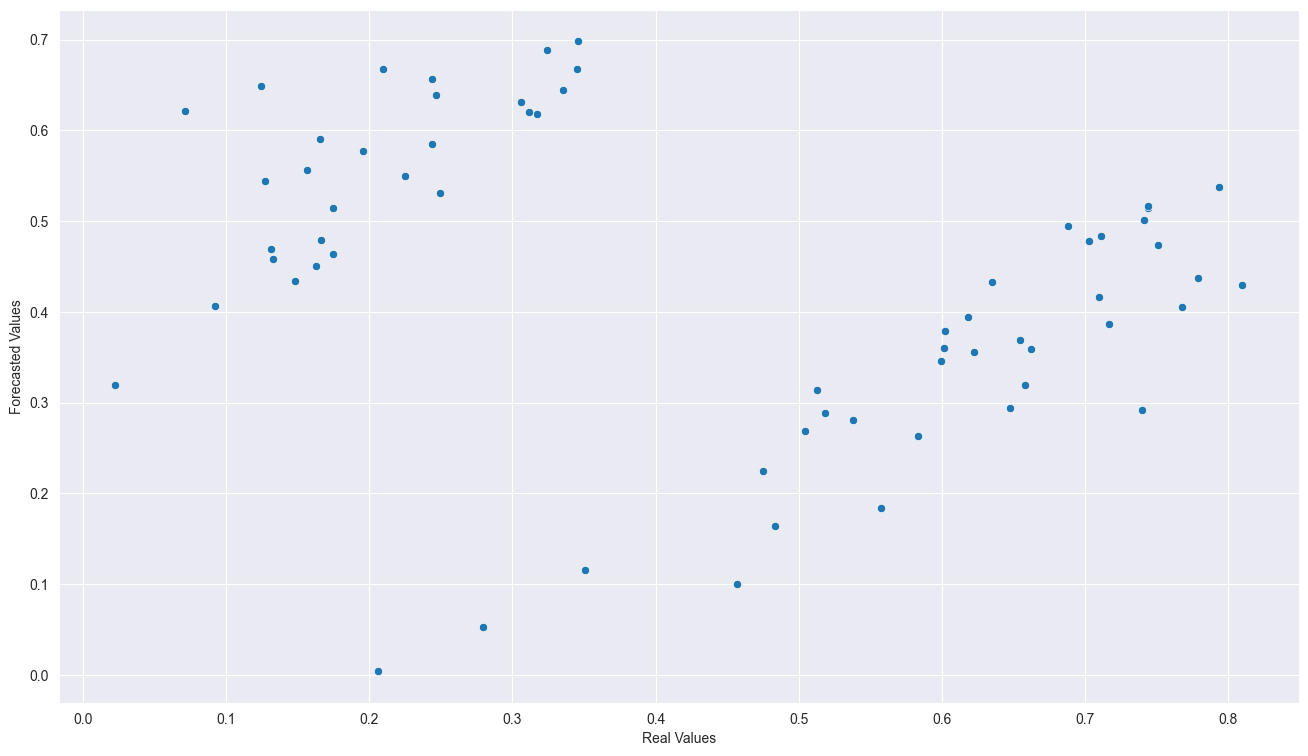

In [95]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Real Data", y = "Val Predictions", data = outliers)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.show()

In [96]:
common_index = data.index.intersection(outliers.index)

initial_df_outliers = data.loc[common_index]

initial_df_outliers

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2024-04-12 12:00:00,0.3451,"Kozani, Greece",22.0,22.0,4.0,30.79,0.0,0.0,0.0,19.7,14.7,110.0,1027.0,50.0,10.0,765.0,2.8,8.0,Partially cloudy,partly-cloudy-day
2024-04-13 15:00:00,0.2494,"Kozani, Greece",25.0,25.0,7.0,31.62,0.0,0.0,0.0,21.2,7.6,100.0,1025.0,25.7,10.0,772.0,2.8,8.0,Partially cloudy,partly-cloudy-day
2024-04-16 11:00:00,0.1331,"Kozani, Greece",21.0,21.0,4.0,32.74,0.0,0.0,0.0,7.9,0.0,0.0,1012.0,50.0,10.0,311.0,1.1,3.0,Partially cloudy,partly-cloudy-day
2024-04-16 12:00:00,0.1274,"Kozani, Greece",20.0,20.0,8.0,45.87,0.0,0.0,0.0,14.2,0.0,0.0,1012.0,50.1,10.0,271.0,1.0,3.0,Partially cloudy,partly-cloudy-day
2024-04-18 14:00:00,0.7398,"Kozani, Greece",14.0,14.0,1.0,41.15,0.0,0.0,0.0,39.2,11.2,330.0,1006.0,50.0,10.0,327.0,1.2,3.0,Partially cloudy,partly-cloudy-day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-17 11:00:00,0.3354,"Kozani, Greece",28.0,26.9,6.0,24.75,0.0,0.0,0.0,10.1,0.0,0.0,1017.0,50.0,10.0,643.0,2.3,6.0,Partially cloudy,partly-cloudy-day
2024-06-17 12:00:00,0.2467,"Kozani, Greece",28.0,27.0,8.0,28.40,0.0,0.0,0.0,15.7,0.0,0.0,1017.0,88.3,10.0,517.0,1.9,5.0,Partially cloudy,partly-cloudy-day
2024-06-23 15:00:00,0.3245,"Kozani, Greece",35.0,33.4,11.0,23.34,0.0,0.0,0.0,22.0,9.4,120.0,1010.0,100.0,24.1,798.0,2.9,8.0,Overcast,cloudy


In [97]:
initial_df_outliers['time'] = initial_df_outliers.index.time
initial_df_outliers

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,...,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon,time
datetime,,,,,,,,,,,,,,,,,,,,,
2024-04-12 12:00:00,0.3451,"Kozani, Greece",22.0,22.0,4.0,30.79,0.0,0.0,0.0,19.7,...,110.0,1027.0,50.0,10.0,765.0,2.8,8.0,Partially cloudy,partly-cloudy-day,12:00:00
2024-04-13 15:00:00,0.2494,"Kozani, Greece",25.0,25.0,7.0,31.62,0.0,0.0,0.0,21.2,...,100.0,1025.0,25.7,10.0,772.0,2.8,8.0,Partially cloudy,partly-cloudy-day,15:00:00
2024-04-16 11:00:00,0.1331,"Kozani, Greece",21.0,21.0,4.0,32.74,0.0,0.0,0.0,7.9,...,0.0,1012.0,50.0,10.0,311.0,1.1,3.0,Partially cloudy,partly-cloudy-day,11:00:00
2024-04-16 12:00:00,0.1274,"Kozani, Greece",20.0,20.0,8.0,45.87,0.0,0.0,0.0,14.2,...,0.0,1012.0,50.1,10.0,271.0,1.0,3.0,Partially cloudy,partly-cloudy-day,12:00:00
2024-04-18 14:00:00,0.7398,"Kozani, Greece",14.0,14.0,1.0,41.15,0.0,0.0,0.0,39.2,...,330.0,1006.0,50.0,10.0,327.0,1.2,3.0,Partially cloudy,partly-cloudy-day,14:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-17 11:00:00,0.3354,"Kozani, Greece",28.0,26.9,6.0,24.75,0.0,0.0,0.0,10.1,...,0.0,1017.0,50.0,10.0,643.0,2.3,6.0,Partially cloudy,partly-cloudy-day,11:00:00
2024-06-17 12:00:00,0.2467,"Kozani, Greece",28.0,27.0,8.0,28.40,0.0,0.0,0.0,15.7,...,0.0,1017.0,88.3,10.0,517.0,1.9,5.0,Partially cloudy,partly-cloudy-day,12:00:00
2024-06-23 15:00:00,0.3245,"Kozani, Greece",35.0,33.4,11.0,23.34,0.0,0.0,0.0,22.0,...,120.0,1010.0,100.0,24.1,798.0,2.9,8.0,Overcast,cloudy,15:00:00


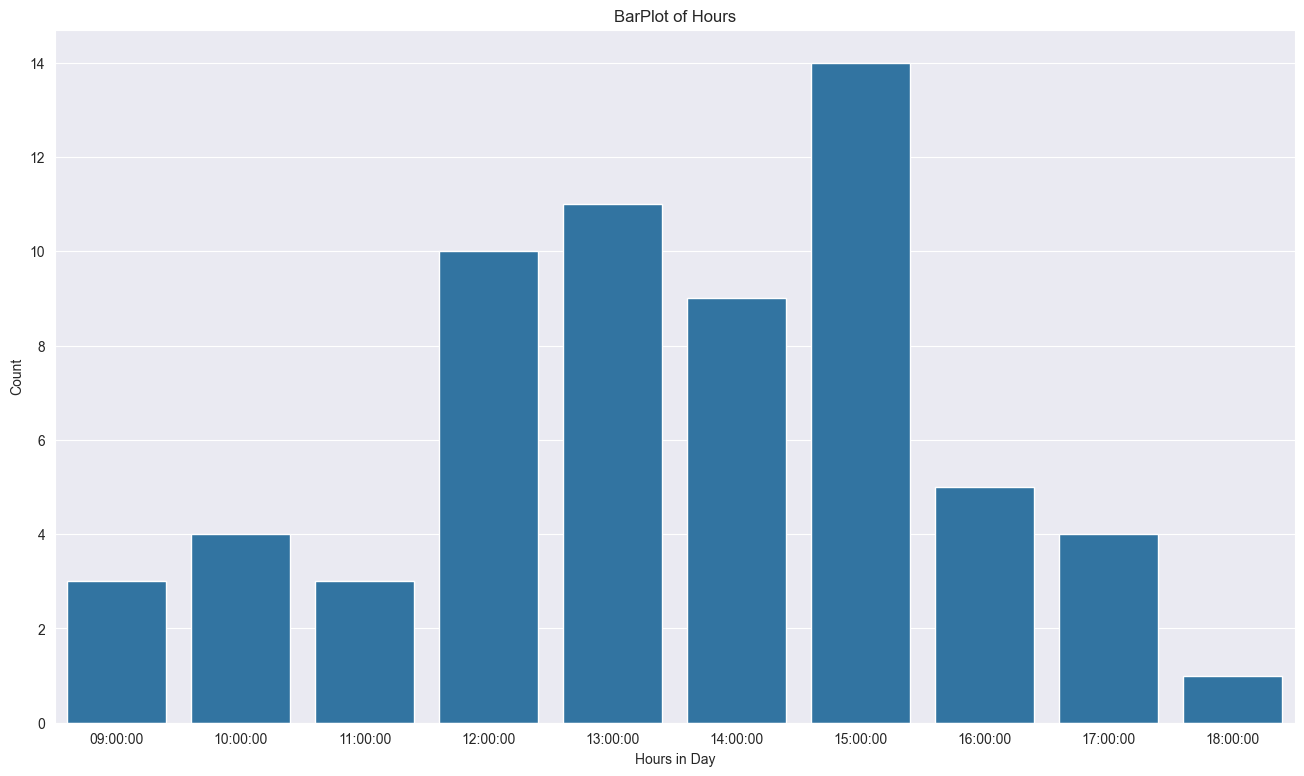

In [98]:
sns.set_style('darkgrid')
plt.figure(figsize= (16, 9))
sns.countplot(x = sorted(initial_df_outliers['time']))
plt.xlabel('Hours in Day')
plt.ylabel("Count")
plt.title("BarPlot of Hours")
plt.show()

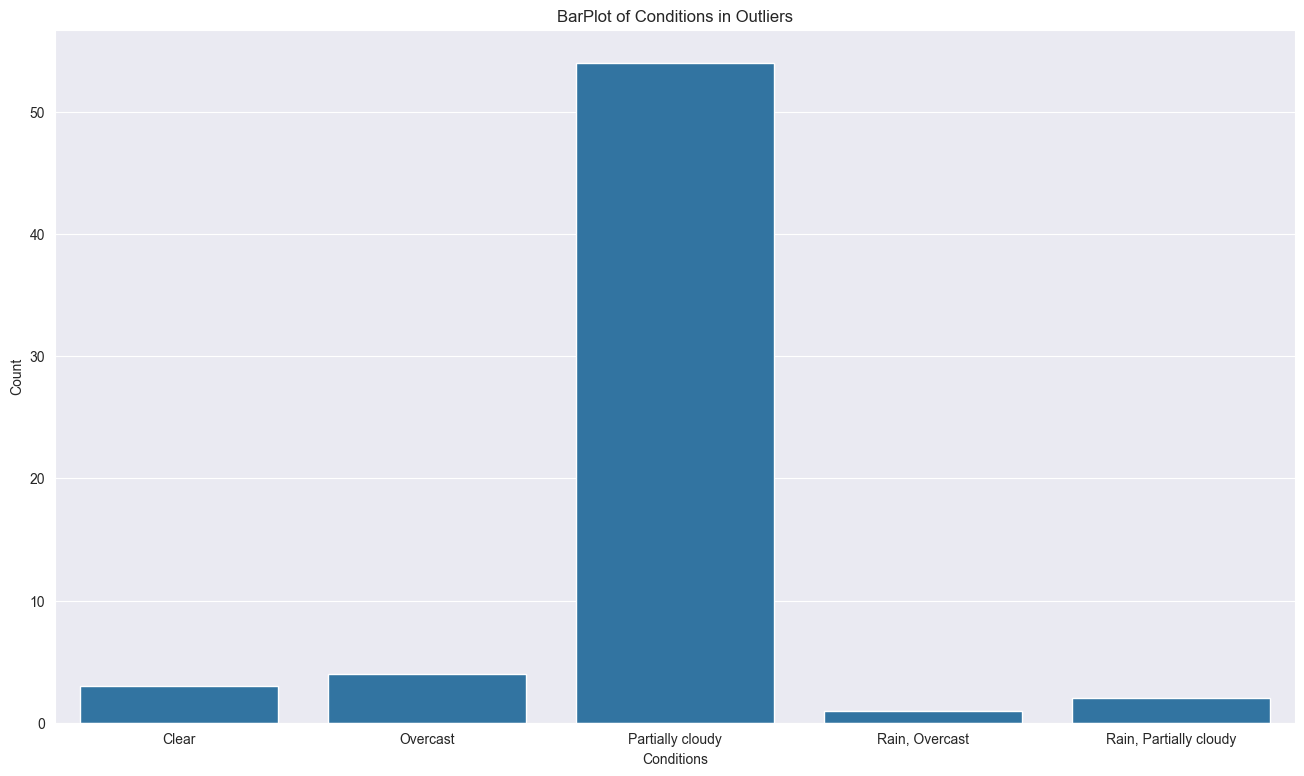

In [99]:
sns.set_style('darkgrid')
plt.figure(figsize= (16, 9))
sns.countplot(x = sorted(initial_df_outliers['conditions']))
plt.xlabel('Conditions')
plt.ylabel("Count")
plt.title("BarPlot of Conditions in Outliers")
plt.show()

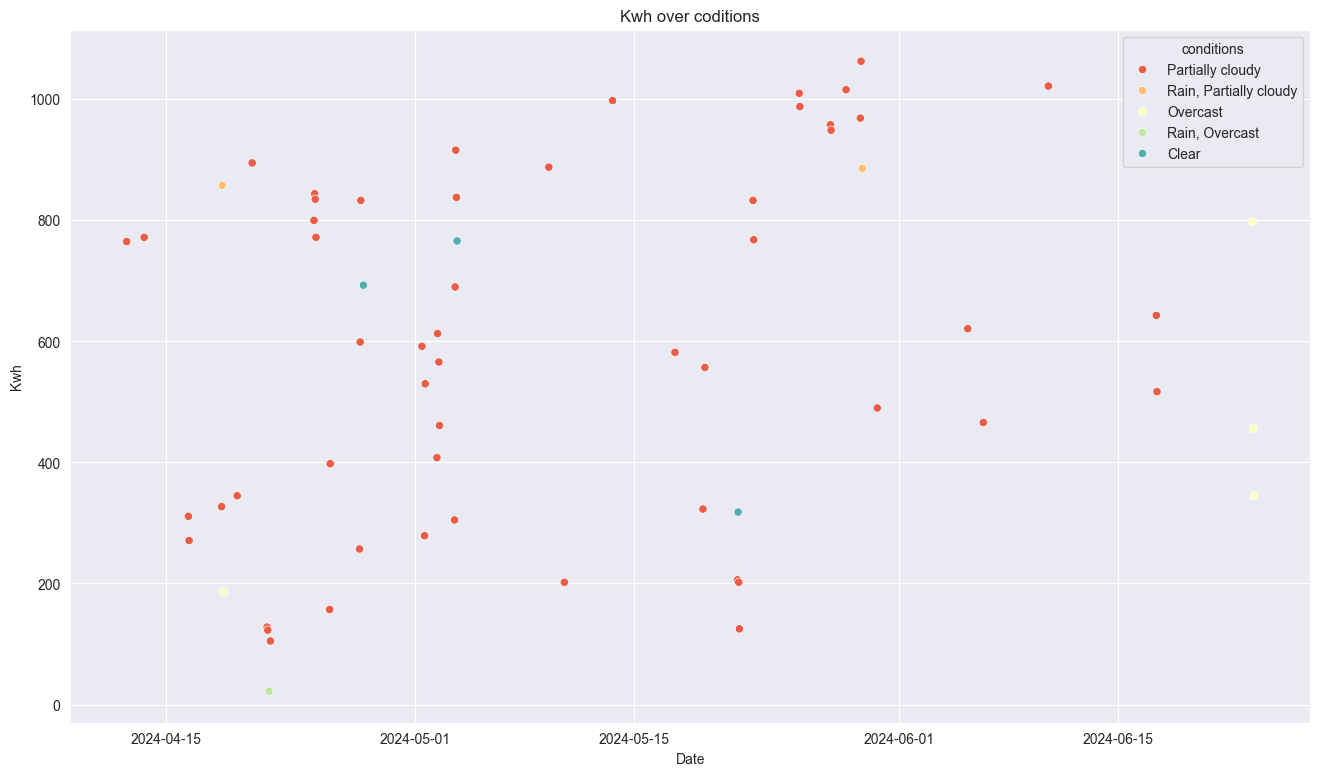

In [100]:
sns.set_style('darkgrid')
plt.figure(figsize= (16, 9))
sns.scatterplot(y = initial_df_outliers['solarradiation'], x= initial_df_outliers.index, hue= initial_df_outliers['conditions'], palette= 'Spectral')
plt.xlabel('Date')
plt.ylabel('Kwh')
plt.title('Kwh over coditions')
plt.show()

In [101]:
initial_df_outliers = pd.concat([initial_df_outliers, outliers['Val Predictions']], axis= 1)
initial_df_outliers

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon,time,Val Predictions
datetime,,,,,,,,,,,,,,,,,,,,,
2024-04-12 12:00:00,0.3451,"Kozani, Greece",22.0,22.0,4.0,30.79,0.0,0.0,0.0,19.7,...,1027.0,50.0,10.0,765.0,2.8,8.0,Partially cloudy,partly-cloudy-day,12:00:00,0.667704
2024-04-13 15:00:00,0.2494,"Kozani, Greece",25.0,25.0,7.0,31.62,0.0,0.0,0.0,21.2,...,1025.0,25.7,10.0,772.0,2.8,8.0,Partially cloudy,partly-cloudy-day,15:00:00,0.531128
2024-04-16 11:00:00,0.1331,"Kozani, Greece",21.0,21.0,4.0,32.74,0.0,0.0,0.0,7.9,...,1012.0,50.0,10.0,311.0,1.1,3.0,Partially cloudy,partly-cloudy-day,11:00:00,0.458478
2024-04-16 12:00:00,0.1274,"Kozani, Greece",20.0,20.0,8.0,45.87,0.0,0.0,0.0,14.2,...,1012.0,50.1,10.0,271.0,1.0,3.0,Partially cloudy,partly-cloudy-day,12:00:00,0.544006
2024-04-18 14:00:00,0.7398,"Kozani, Greece",14.0,14.0,1.0,41.15,0.0,0.0,0.0,39.2,...,1006.0,50.0,10.0,327.0,1.2,3.0,Partially cloudy,partly-cloudy-day,14:00:00,0.291516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-17 11:00:00,0.3354,"Kozani, Greece",28.0,26.9,6.0,24.75,0.0,0.0,0.0,10.1,...,1017.0,50.0,10.0,643.0,2.3,6.0,Partially cloudy,partly-cloudy-day,11:00:00,0.644550
2024-06-17 12:00:00,0.2467,"Kozani, Greece",28.0,27.0,8.0,28.40,0.0,0.0,0.0,15.7,...,1017.0,88.3,10.0,517.0,1.9,5.0,Partially cloudy,partly-cloudy-day,12:00:00,0.639261
2024-06-23 15:00:00,0.3245,"Kozani, Greece",35.0,33.4,11.0,23.34,0.0,0.0,0.0,22.0,...,1010.0,100.0,24.1,798.0,2.9,8.0,Overcast,cloudy,15:00:00,0.688136


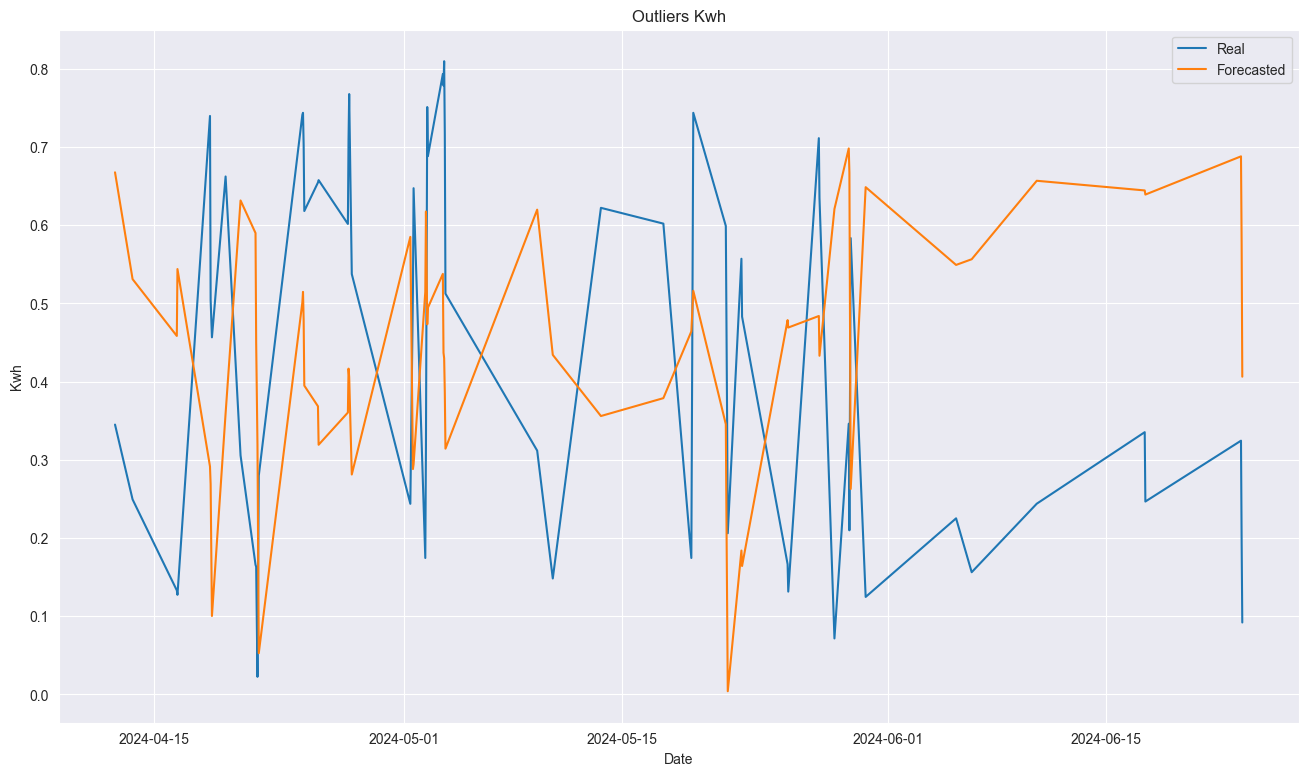

In [102]:
sns.set_style('darkgrid')
plt.figure(figsize= (16, 9))
sns.lineplot(x = initial_df_outliers.index, y = initial_df_outliers['Kwh'], label = "Real")
sns.lineplot(x = initial_df_outliers.index, y = initial_df_outliers['Val Predictions'], label = "Forecasted")
plt.xlabel('Date')
plt.legend()
plt.ylabel('Kwh')
plt.title('Outliers Kwh')
plt.show()